In this notebook, we demonstrate how to load any data layer from CoRE Stack using STAC catalog:
1. selecting a specific layer from the catalog

2. giving a bounding box of interest and then selecting layers from it. 

In [1]:
import pystac
import pandas as pd
import geopandas as gpd
from pystac import MediaType
from shapely.geometry import box
import rasterio
import rasterio.plot
import requests

In [2]:
# s3_url = 'https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/CorestackCatalogs/catalog.json'
s3_url = 'https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/CorestackCatalogs_merged_collection/tehsil_wise/catalog.json'
catalog = pystac.Catalog.from_file(s3_url)


In [3]:
print(f"Catalog ID: {catalog.id}")
print(f"Description: {catalog.description}")
# print(f"STAC Version: {catalog.stac_version}")

Catalog ID: tehsil_wise
Description: This spatio temporal asset catalog contains all data layers of CoREStack (https://core-stack.org/). The data layers are generated at an administrative tehsil level.


In [4]:
collections = list(catalog.get_collections())

print(f"Number of collections: {len(collections)}")
print("Collections IDs:")
for collection in collections:
    print(f"- {collection.id}")

Number of collections: 22
Collections IDs:
- jharkhand
- bihar
- odisha
- uttar_pradesh
- karnataka
- rajasthan
- maharashtra
- gujarat
- andhra_pradesh
- assam
- chhattisgarh
- delhi
- goa
- haryana
- himachal_pradesh
- madhya_pradesh
- meghalaya
- west_bengal
- nagaland
- tamil_nadu
- telangana
- kerala


Select **state** name

In [5]:
state_collection = catalog.get_child(id='maharashtra') #choose any state of interest, and select the name based on how its available in the collections (printed above)

In [6]:
item_data = []
items_df = pd.DataFrame()

for root, catalogs, items in state_collection.walk():
    for item in items:
        # Extract core properties. You can add more properties/extensions as needed.
        # item_mediatype = ''
        
        itemdata_mediatype = item.assets['data'].media_type
 
        data = {
            'id': item.id,
            'datetime': item.datetime.isoformat() if item.datetime else None,
            # 'collection_id': item.collection_id,
            'catalog_id' : item.get_parent(),
            'bbox': item.bbox,
            'self_link': item.get_self_href(),
            'item_type' : itemdata_mediatype,
            'data_link' : item.assets['data'].href 
        }
        item_data.append(data)

    # Convert the list of dictionaries to a pandas DataFrame for a clean table view
    items_df = pd.DataFrame(item_data)

Give bounding box of area of interest to filter data layers intersecting in the area. 

In [7]:
# Define your bounding box as a shapely geometry

target_bbox_coords = [73.168859,19.598849,75.849524,21.164163] #near nashik

#to choose bounding box in any other state, first select the specific state and get the items 
# target_bbox_coords = [74.992633,12.083932,77.947955,16.184631] #karnataka

target_bbox_shape = box(*target_bbox_coords)

filtered_items = []
for index,row in items_df.iterrows():
    # Create a shapely box from the item's STAC bbox property
    item_bbox_shape = box(*row.bbox)

    # Check for intersection
    if item_bbox_shape.intersects(target_bbox_shape):
        filtered_items.append(item)

print(f"Found {len(filtered_items)} items in the static catalog matching the bbox.")

Found 499 items in the static catalog matching the bbox.


In [8]:
items_df['id'].to_dict()

{0: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2017',
 1: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2018',
 2: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2019',
 3: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2020',
 4: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2021',
 5: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2022',
 6: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2023',
 7: 'maharashtra_amaravati_anjangaon-surji_land_use_land_cover_raster_2024',
 8: 'maharashtra_amaravati_anjangaon-surji_terrain_raster',
 9: 'maharashtra_amaravati_anjangaon-surji_clart_raster',
 10: 'maharashtra_amaravati_anjangaon-surji_wri_restoration_raster',
 11: 'maharashtra_amaravati_anjangaon-surji_natural_depressions_raster',
 12: 'maharashtra_amaravati_anjangaon-surji_stream_order_raster',
 13: 'maharashtra_amaravati_anjangaon-surji_distance_to_up

Select item of interest e.g. cropping intensity in surgana, nashik

In [9]:
vector_item_df = items_df[items_df['id'] == 'maharashtra_nashik_surgana_cropping_intensity_vector']
vector_item_df

,id,datetime,catalog_id,bbox,self_link,item_type,data_link
624,maharashtra_nashik_surgana_cropping_intensity_...,2026-01-21T10:46:29.494801+00:00,<Collection id=surgana>,"[73.37570737, 20.33376833, 73.84516595, 20.739...",https://spatio-temporal-asset-catalog.s3.ap-so...,application/geo+json,https://geoserver.core-stack.org:8443/geoserve...


In a vector item, link to the data url is under **assets** -> **data**

In [10]:
vector_data_df = gpd.GeoDataFrame.from_file(vector_item_df['data_link'].iloc[0])

In [11]:
vector_data_df.head()

,area_in_ha,cropping_intensity_2017,cropping_intensity_2018,cropping_intensity_2019,cropping_intensity_2020,cropping_intensity_2021,cropping_intensity_2022,cropping_intensity_2023,cropping_intensity_2024,doubly_cropped_area_2017,...,triply_cropped_area_2017,triply_cropped_area_2018,triply_cropped_area_2019,triply_cropped_area_2020,triply_cropped_area_2021,triply_cropped_area_2022,triply_cropped_area_2023,triply_cropped_area_2024,uid,geometry
0,783.493301,0.490176,0.838863,1.018834,1.043671,1.039524,0.680955,1.009415,0.862306,19.208728,...,0.018618,0.139629,2.437605,37.833230,1.703399,3.499375,0.102399,26.010048,25_19350,"MULTIPOLYGON (((73.5207 20.67064, 73.5207 20.6..."
1,676.744847,0.478028,1.174361,1.315961,0.928792,1.103111,0.718352,1.010236,1.440181,15.984350,...,0.000000,2.767351,35.566472,26.309646,15.889391,6.969326,8.565925,36.844823,25_25342,"MULTIPOLYGON (((73.5118 20.62132, 73.5118 20.6..."
2,687.718764,0.570918,0.809523,1.331266,0.917133,1.151223,1.155220,1.188879,1.269947,58.873285,...,1.258431,8.477386,15.049248,24.086869,15.191751,13.570564,14.837718,65.747369,25_29889,"MULTIPOLYGON (((73.49671 20.44696, 73.49725 20..."
3,714.567519,0.689416,1.061621,1.405109,1.009905,1.324757,1.025461,1.196906,1.180368,92.022279,...,1.081446,6.093194,19.209423,43.682013,28.540291,16.183137,4.830959,44.434824,25_30141,"MULTIPOLYGON (((73.42906 20.43968, 73.42906 20..."
4,1209.708285,0.517209,0.965443,0.782240,0.882442,1.060448,0.772034,1.303162,1.269086,94.390882,...,0.148955,7.367833,11.628426,44.522867,22.799448,10.015017,10.332719,60.434848,25_22995,"MULTIPOLYGON (((73.4288 20.65015, 73.42906 20...."


* Example of a raster item

In [12]:
raster_item_df = items_df[items_df['id'] == 'maharashtra_nashik_surgana_land_use_land_cover_raster_2024']
raster_item_df

,id,datetime,catalog_id,bbox,self_link,item_type,data_link
609,maharashtra_nashik_surgana_land_use_land_cover...,2026-01-21T10:46:13.956230+00:00,<Collection id=surgana>,"[73.37556021675186, 20.333635950630605, 73.845...",https://spatio-temporal-asset-catalog.s3.ap-so...,image/tiff; application=geotiff,https://geoserver.core-stack.org:8443/geoserve...


Download the tiff and plot

In [13]:
response = requests.get(raster_item_df['data_link'].iloc[0])

if response.status_code == 200:
    # Use MemoryFile to treat the downloaded bytes as a file
    with rasterio.MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            print(f"CRS: {src.crs}")
            print(f"Shape: {src.shape}")
            data = src.read(1)

CRS: EPSG:4326
Shape: (4518, 5229)


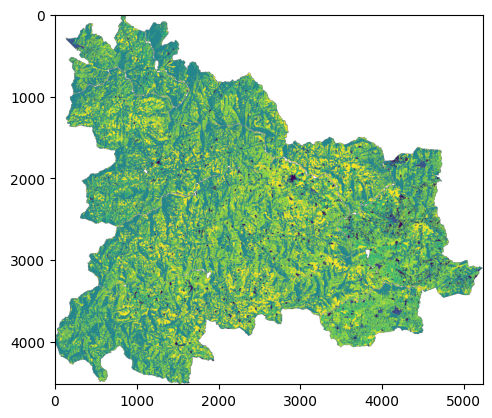

In [14]:
image_plot = rasterio.plot.show(data)